In [1]:
import ROOT
from IPython.display import Image, display

#### Importar ROOT
```python
-> import ROOT
``` 
se encarga de cargar la librería de PyROOT dentro de Python o Jupyter.

In [2]:
ROOT.gROOT.SetBatch(True)

root_files = [
    "../../data/00334560_00000001_1.dvntuple.root",
    "../../data/00334560_00000002_1.dvntuple.root",
    "../../data/00334564_00000001_1.dvntuple.root",
    "../../data/00334565_00000001_1.dvntuple.root",
    "../../data/00334566_00000001_1.dvntuple.root",
]
rdf = ROOT.RDataFrame("Btree/DecayTree", root_files)

```python
-> ROOT.gROOT.SetBatch(True)
``` 
evita que ROOT intente abrir ventanas gráficas interactivas. Es útil para trabajar con Jupyter, VSCode, terminal o servidores de interfaz gráfica.

#### Definición de archivos ROOT
```python
-> root_files = []
```
Define una lista de archivos `.root` que serán usados por `RDataFrame`. Puede realizarse de forma remota
```python
root_files = [
    "root://eospublic.cern.ch/<ruta al archivo>.root"
]
```
Aunque el archivo esté en CERN, ROOT puede leerlo de manera directa usando el protocolo `root://`, siempre que se tenga soporte XRootD.

De manera local se puede definir
```python
root_files = [
    "<carpeta>/<archivo>.dvntuple.root"
]
```

#### Creación de RDataFrame
```python
rdf = ROOT.RDataFrame("BTree/DecayTree", root_files)
```
crea un dataframe a partir del árbol `Btree/DecayTree`.

## Análisis exploratorio de columnas

#### Listar columnas disponibles
Se obtienen los nombres de todas las columnas/branches del árbol.

In [3]:
columns = sorted([str(c) for c in rdf.GetColumnNames()])
for col in columns:
    print(col)

BCID
BCType
Bplus_DIRA_OWNPV
Bplus_ENDVERTEX_CHI2
Bplus_ENDVERTEX_COV_
Bplus_ENDVERTEX_NDOF
Bplus_ENDVERTEX_X
Bplus_ENDVERTEX_XERR
Bplus_ENDVERTEX_Y
Bplus_ENDVERTEX_YERR
Bplus_ENDVERTEX_Z
Bplus_ENDVERTEX_ZERR
Bplus_FDCHI2_OWNPV
Bplus_FD_OWNPV
Bplus_ID
Bplus_IPCHI2_OWNPV
Bplus_IP_OWNPV
Bplus_M
Bplus_MM
Bplus_MMERR
Bplus_OWNPV_CHI2
Bplus_OWNPV_COV_
Bplus_OWNPV_NDOF
Bplus_OWNPV_X
Bplus_OWNPV_XERR
Bplus_OWNPV_Y
Bplus_OWNPV_YERR
Bplus_OWNPV_Z
Bplus_OWNPV_ZERR
Bplus_P
Bplus_PE
Bplus_PT
Bplus_PX
Bplus_PY
Bplus_PZ
EventInSequence
GpsTime
HLT1TCK
HLT2TCK
J_psi_1S_DIRA_ORIVX
J_psi_1S_DIRA_OWNPV
J_psi_1S_ENDVERTEX_CHI2
J_psi_1S_ENDVERTEX_COV_
J_psi_1S_ENDVERTEX_NDOF
J_psi_1S_ENDVERTEX_X
J_psi_1S_ENDVERTEX_XERR
J_psi_1S_ENDVERTEX_Y
J_psi_1S_ENDVERTEX_YERR
J_psi_1S_ENDVERTEX_Z
J_psi_1S_ENDVERTEX_ZERR
J_psi_1S_FDCHI2_ORIVX
J_psi_1S_FDCHI2_OWNPV
J_psi_1S_FD_ORIVX
J_psi_1S_FD_OWNPV
J_psi_1S_ID
J_psi_1S_IPCHI2_OWNPV
J_psi_1S_IP_OWNPV
J_psi_1S_M
J_psi_1S_MM
J_psi_1S_MMERR
J_psi_1S_ORIVX_CHI2
J_psi_1S_OR

## Histograma de Masa

Se grafica la masa reconstruida del candidato `Bplus_M` y del candidato `J_psi_1S_M`.

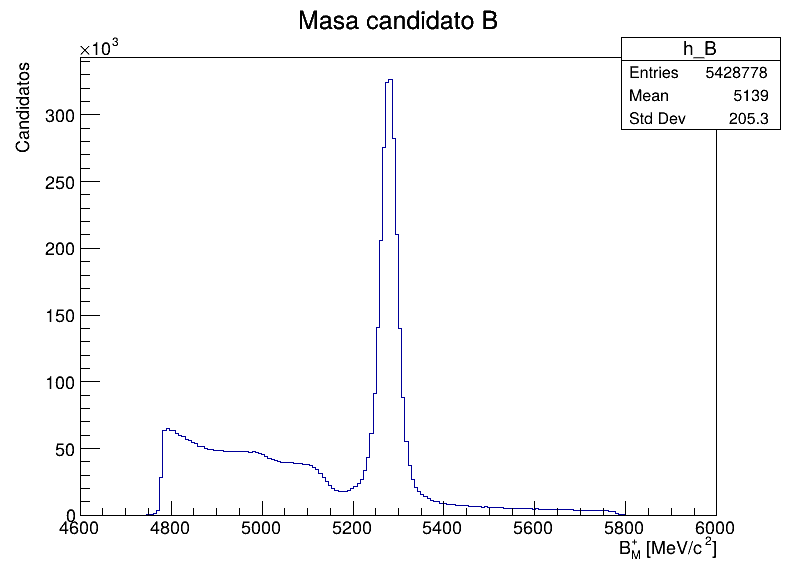

Info in <TCanvas::Print>: png file figs/p01_bmass01.png has been created


In [4]:
hist_B = rdf.Histo1D(
    ("h_B", "Masa candidato B;B^{+}_{M} [MeV/c^{2}];Candidatos", 200, 4600, 6000),
    "Bplus_M"
)
canvas = ROOT.TCanvas("canvas", "", 800,600)
hist_B.Draw()
canvas.SaveAs("figs/p01_bmass01.png")
display(Image("figs/p01_bmass01.png"))

En este gráfico se puede observar si un pico alrededor de la masa esperada del mesón $B$.

## Cortes físicos

Se seleccionan eventos que cumplan ciertas condiciones. En este caso se busca dejar candidatos donde la masa del $J/\psi$ está cerca de su región esperada.

Los cortes sirven para reducir el fondo y mejorar la señal. Los ntuples contienen información de eventos o candidatos, como masa, decisiones de trigger o variables reconstruidas.

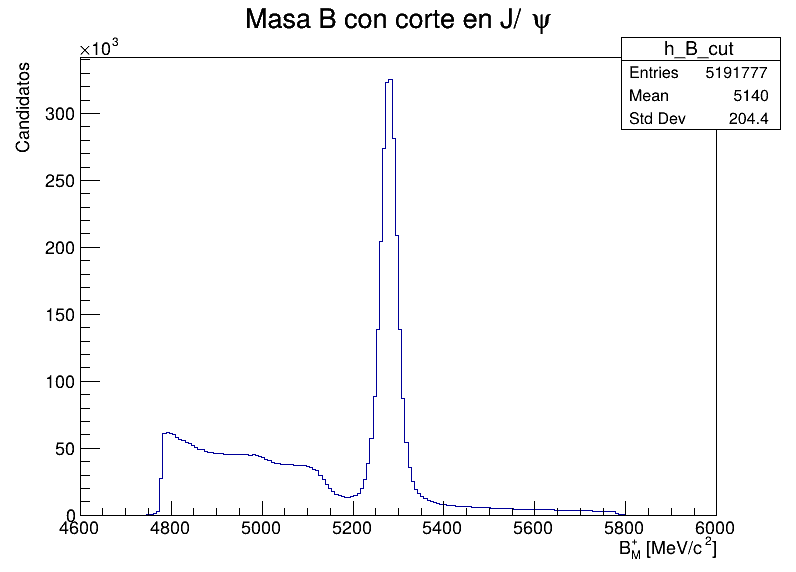

Info in <TCanvas::Print>: png file figs/p01_bmass_jpsi_cut01.png has been created


In [5]:
rdf_cut = rdf.Filter(
    "J_psi_1S_M > 3050 && J_psi_1S_M < 3150",
    "Corte en masa de J/psi"
)

hist_B_cut = rdf_cut.Histo1D(
    ("h_B_cut", "Masa B con corte en J/#psi;B^{+}_{M} [MeV/c^{2}];Candidatos", 200,4600,6000),
    "Bplus_M"
)

canvas = ROOT.TCanvas("canvas_cut", "", 800,600)
hist_B_cut.Draw()
canvas.SaveAs("figs/p01_bmass_jpsi_cut01.png")
display(Image("figs/p01_bmass_jpsi_cut01.png"))

## Comparación

Este análisis sirve para mostrar cómo cambia la distribución cuando se aplica una selección.

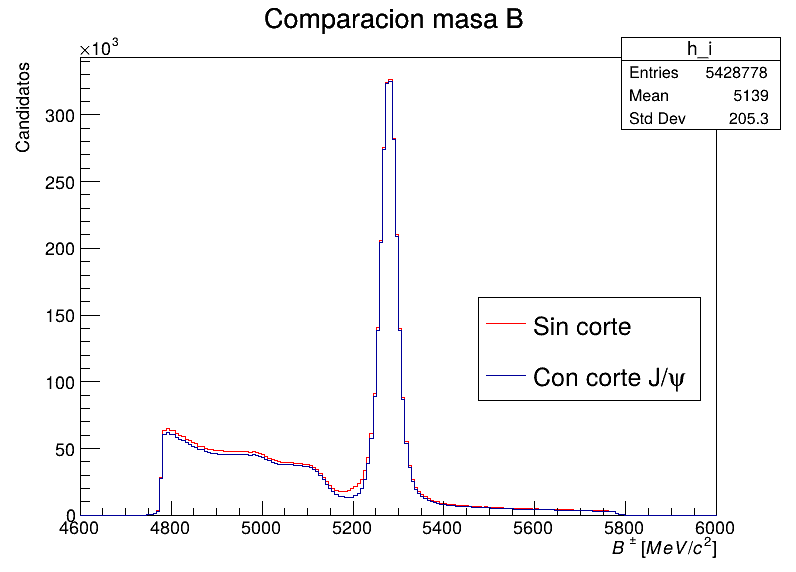

Info in <TCanvas::Print>: png file figs/p01_comparacion_cortes.png has been created


In [6]:
hist_i = rdf.Histo1D(
    ("h_i", "Comparacion masa B;B^{$\pm$} [MeV/c^{2}];Candidatos", 200, 4600,6000),
    "Bplus_M"
)

hist_f = rdf_cut.Histo1D(
    ("h_f", "Comparacion masa B;B^{$\pm$} [MeV/c^{2}];Candidatos", 200, 4600,6000),
    "Bplus_M"
)

canvas = ROOT.TCanvas("Comparación","", 800, 600)

hist_i.SetLineColor(ROOT.kRed)
hist_i.SetLineWidth(1)
hist_f.SetLineWidth(1)

hist_i.Draw()
hist_f.Draw("SAME")

legend = ROOT.TLegend(0.60, 0.30, 0.88, 0.48)
legend.AddEntry(hist_i.GetPtr(), "Sin corte", "l")
legend.AddEntry(hist_f.GetPtr(), "Con corte J/#psi", "l")
legend.Draw()

canvas.SaveAs("figs/p01_comparacion_cortes.png")
display(Image("figs/p01_comparacion_cortes.png"))

## Eficiencia de Cortes

Verificación de los candidatos que quedan despues del filtro.

In [7]:
rdf_sel = (
    rdf
    .Filter("J_psi_1S_M > 3050 && J_psi_1S_M < 3150", "Ventana J/psi")
    .Filter("Bplus_M > 5000 && Bplus_M < 560", "Ventana B")
)
report = rdf_sel.Report()
report.Print()

Ventana J/psi: pass=5191777    all=5428778    -- eff=95.63 % cumulative eff=95.63 %
Ventana B : pass=0          all=5191777    -- eff=0.00 % cumulative eff=0.00 %


## Ajuste de Masa

Ajuste de la distribución de masa del $B$ con una función. Se emplea una distribución gausiana `gaus`.

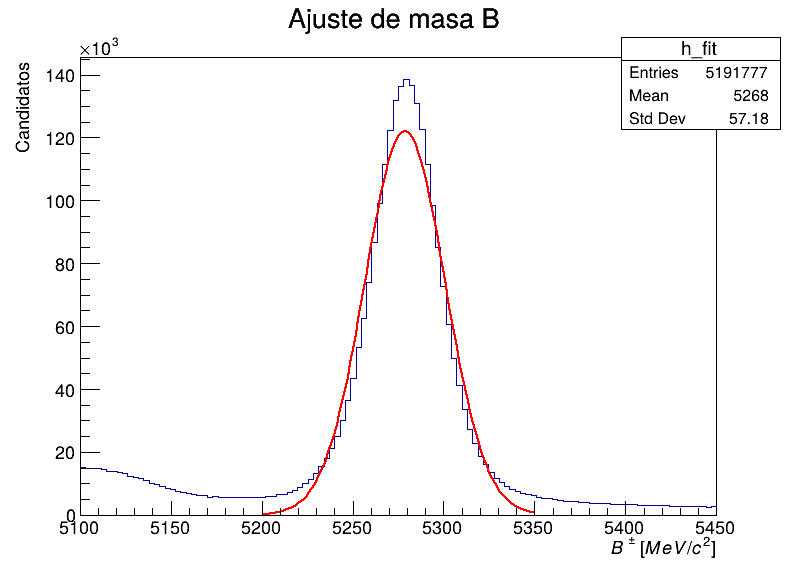

****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      90199.1
NDf                       =           49
Edm                       =  2.90296e-06
NCalls                    =           76
Constant                  =       122057   +/-   114.53      
Mean                      =      5278.85   +/-   0.0145959   
Sigma                     =      22.0897   +/-   0.0149179    	 (limited)


Info in <TCanvas::Print>: png file figs/p01_fit_bmass.png has been created


In [8]:
hist_fit = rdf_cut.Histo1D(
    ("h_fit", "Ajuste de masa B;B^{$\pm$} [MeV/c^{2}];Candidatos", 120, 5100, 5450),
    "Bplus_M"
)

canvas = ROOT.TCanvas("fit_canvas", "", 800, 600)
hist_fit.Draw()
fit_result = hist_fit.Fit("gaus", "S", "", 5200, 5350)
canvas.SaveAs("figs/p01_fit_bmass.png")
display(Image("figs/p01_fit_bmass.png"))

In [9]:
fit_function = hist_fit.GetFunction("gaus")
print("Media aproximada:", fit_function.GetParameter(1))
print("Sigma aproximada:", fit_function.GetParameter(2))

Media aproximada: 5278.852667382144
Sigma aproximada: 22.08968746345575


## Distribuciones cinemáticas

Anpalisis de variables como momentum total, momentum transversal o pseudorapidez.

In [10]:
for col in columns:
    if "_PT" in col or "_P" in col or "_ETA" in col:
        print(col)

Bplus_P
Bplus_PE
Bplus_PT
Bplus_PX
Bplus_PY
Bplus_PZ
J_psi_1S_P
J_psi_1S_PE
J_psi_1S_PT
J_psi_1S_PX
J_psi_1S_PY
J_psi_1S_PZ
Kplus_MC12TuneV2_ProbNNe
Kplus_MC12TuneV2_ProbNNghost
Kplus_MC12TuneV2_ProbNNk
Kplus_MC12TuneV2_ProbNNmu
Kplus_MC12TuneV2_ProbNNp
Kplus_MC12TuneV2_ProbNNpi
Kplus_MC12TuneV3_ProbNNe
Kplus_MC12TuneV3_ProbNNghost
Kplus_MC12TuneV3_ProbNNk
Kplus_MC12TuneV3_ProbNNmu
Kplus_MC12TuneV3_ProbNNp
Kplus_MC12TuneV3_ProbNNpi
Kplus_MC12TuneV4_ProbNNe
Kplus_MC12TuneV4_ProbNNghost
Kplus_MC12TuneV4_ProbNNk
Kplus_MC12TuneV4_ProbNNmu
Kplus_MC12TuneV4_ProbNNp
Kplus_MC12TuneV4_ProbNNpi
Kplus_MC15TuneV1_ProbNNe
Kplus_MC15TuneV1_ProbNNghost
Kplus_MC15TuneV1_ProbNNk
Kplus_MC15TuneV1_ProbNNmu
Kplus_MC15TuneV1_ProbNNp
Kplus_MC15TuneV1_ProbNNpi
Kplus_P
Kplus_PE
Kplus_PIDK
Kplus_PIDd
Kplus_PIDe
Kplus_PIDmu
Kplus_PIDp
Kplus_PT
Kplus_PX
Kplus_PY
Kplus_PZ
Kplus_ProbNNd
Kplus_ProbNNe
Kplus_ProbNNghost
Kplus_ProbNNk
Kplus_ProbNNmu
Kplus_ProbNNp
Kplus_ProbNNpi
muminus_MC12TuneV2_ProbNNe
muminus_MC12

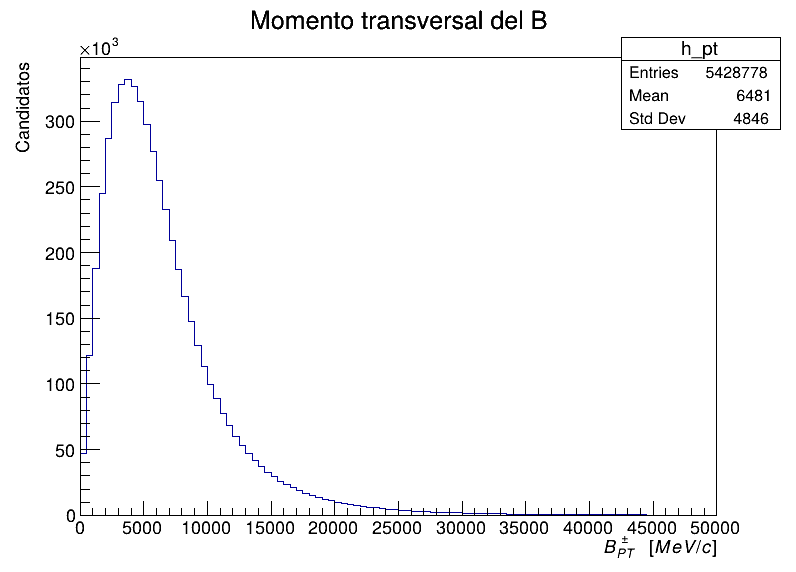

Info in <TCanvas::Print>: png file figs/p01_bplus_pt.png has been created


In [11]:
hist_pt = rdf.Histo1D(
    ("h_pt", "Momento transversal del B;B^{$\pm$}_{PT}$\,$[MeV/c];Candidatos", 100, 0, 50000),
    "Bplus_PT"
)

canvas = ROOT.TCanvas("pt_canvas", "", 800, 600)
hist_pt.Draw()
canvas.SaveAs("figs/p01_bplus_pt.png")
display(Image("figs/p01_bplus_pt.png"))

Comparración entre `Bplus_PT`, `Kplus_PT`, `muplus_PT` y `muminus_PT`:

## Histogramas 2D

Empleado para estudiar realciones entre variables. En este caso, se busca una relación entre la masa del $B$ vs la masa del $J/\psi$. Sirve ara ver si hay correlaciones o regiones donde se concentran los candidatos.

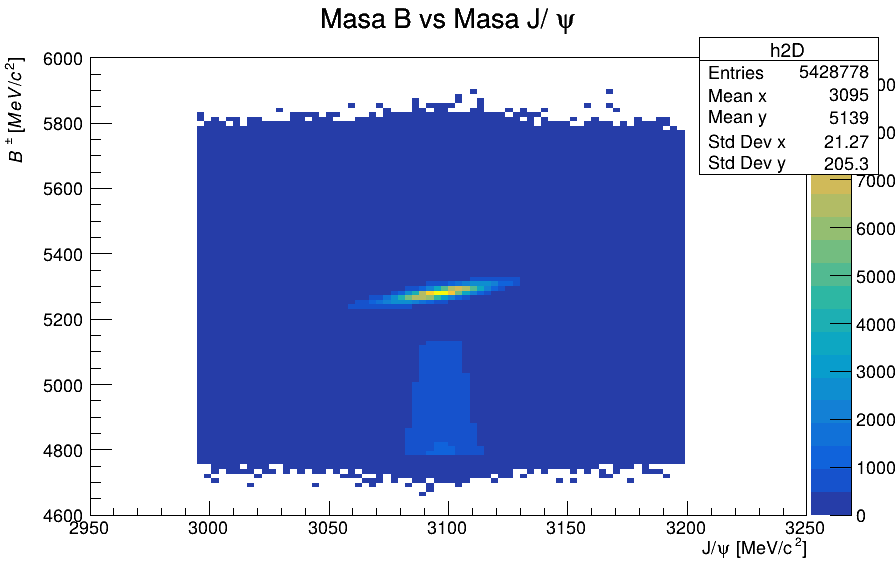

Info in <TCanvas::Print>: png file figs/p01_bmasa_2d.png has been created


In [12]:
hist_2D = rdf.Histo2D(
    (
        "h2D",
        "Masa B vs Masa J/#psi;J/#psi [MeV/c^{2}];B^{$\pm$} [MeV/c^{2}]",
        100, 2950, 3250,
        100, 4600, 6000
    ),
    "J_psi_1S_M",
    "Bplus_M"
)

canvas = ROOT.TCanvas("canvas_2d", "", 900, 600)
hist_2D.Draw("COLZ")
canvas.SaveAs("figs/p01_bmasa_2d.png")
display(Image("figs/p01_bmasa_2d.png"))

In [13]:
ROOT.gStyle.SetOptStat(0)
canvas.SetLogz()
hist_2D.Draw("COLZ")
canvas.SaveAs("figs/p01_bmasa_2d_log.png")
# display(Image("figs/bmasa_2d_log.png"))

Info in <TCanvas::Print>: png file figs/p01_bmasa_2d_log.png has been created


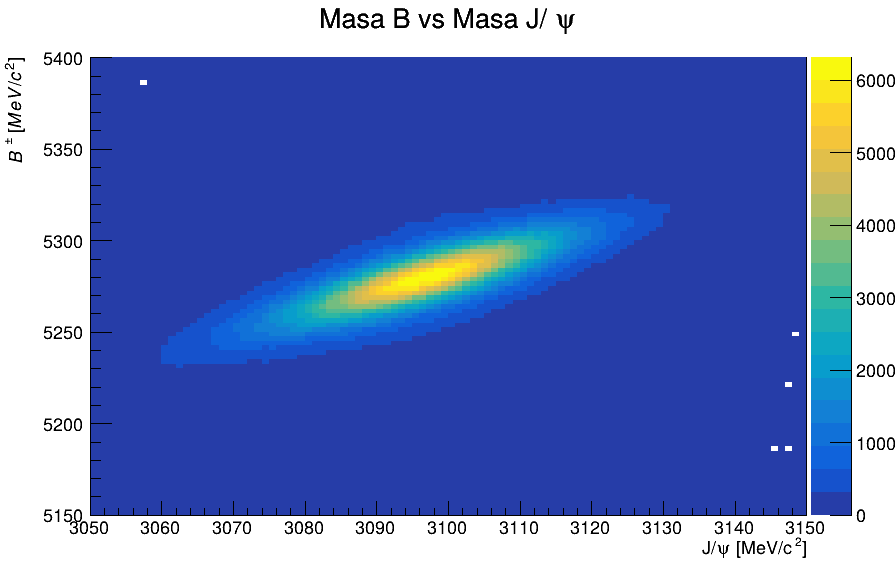

Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas_2d
Info in <TCanvas::Print>: png file figs/p01_bmasa_2dz.png has been created


In [14]:
hist_2Dz = rdf.Histo2D(
    (
        "h2Dz",
        "Masa B vs Masa J/#psi;J/#psi [MeV/c^{2}];B^{$\pm$} [MeV/c^{2}]",
        100, 3050, 3150,
        100, 5150, 5400
    ),
    "J_psi_1S_M",
    "Bplus_M"
)

canvas = ROOT.TCanvas("canvas_2d", "", 900, 600)
hist_2Dz.Draw("COLZ")
canvas.SaveAs("figs/p01_bmasa_2dz.png")
display(Image("figs/p01_bmasa_2dz.png"))

## Separación de $B^{+}$ y $B^{-}$

Dado que el dataset es de $B^{\pm}$, se pueden comparar los candidatos positivos y negativos. Para esto se buscan columnas relacionadas con carga o ID.

In [15]:
for col in columns:
    if "ID"  in col or "CHARGE" in col or "Q" in col:
        print(col)

BCID
Bplus_ID
J_psi_1S_ID
Kplus_ID
Kplus_PIDK
Kplus_PIDd
Kplus_PIDe
Kplus_PIDmu
Kplus_PIDp
muminus_ID
muminus_PIDK
muminus_PIDd
muminus_PIDe
muminus_PIDmu
muminus_PIDp
muplus_ID
muplus_PIDK
muplus_PIDd
muplus_PIDe
muplus_PIDmu
muplus_PIDp


In [16]:
rdf_bplus = rdf.Filter("Bplus_ID > 0", "B+")
rdf_bminus = rdf.Filter("Bplus_ID < 0", "B-")

h_plus = rdf_bplus.Histo1D(
    ("h_plus", "Masa B;B^{+}_{M} [MeV/c^{2}];Candidatos", 120, 5100, 5450),
    "Bplus_M"
)
h_minus = rdf_bminus.Histo1D(
    ("h_minus", "Masa B-;B^{+}_{M} [MeV/c^{2}];Candidatos", 120, 5100, 5450),
    "Bplus_M"
)

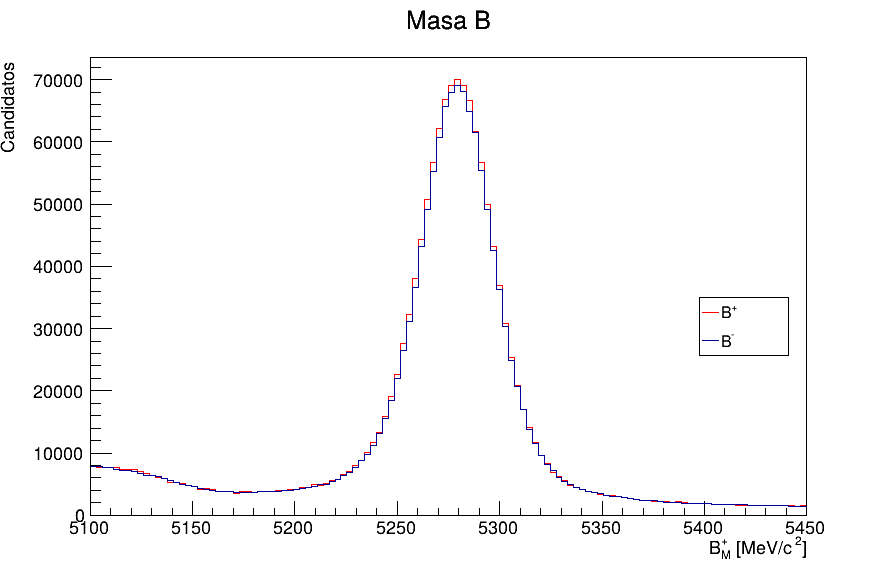

Info in <TCanvas::Print>: png file figs/p01_bplus_minus.png has been created


In [17]:
canvas = ROOT.TCanvas("B","", 900, 600)
h_plus.SetLineColor(ROOT.kRed)
h_plus.SetLineWidth(1)
h_minus.SetLineWidth(1)

h_plus.Draw()
h_minus.Draw("SAME")

blegend = ROOT.TLegend(0.78, 0.38, 0.88, 0.48)
blegend.SetTextSize(0.030)
blegend.AddEntry(h_plus.GetPtr(), "B^{+}", "l")
blegend.AddEntry(h_minus.GetPtr(), "B^{-}", "l")
blegend.Draw()

canvas.SaveAs("figs/p01_bplus_minus.png")
display(Image("figs/p01_bplus_minus.png"))